SECTION 0: README

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.graph_objects as go

SECTION 1: Data Cleaning & Loading

In [2]:
df1 = pd.read_csv('AAPL_Stock_Price_Dataset_NEW.csv')
df2 = pd.read_csv('HistoricalQuotes_NEW.csv')

df1['Date'] = pd.to_datetime(df1['Date'])
df2['Date'] = pd.to_datetime(df2['Date'])

df2.columns = df2.columns.str.strip()
df2 = df2.rename(columns={'Close/Last':'Close'})

merged = df2.merge(df1, how="inner", on="Date", suffixes=('_Splits','_NoSplits'))
merged['Profit'] = merged['Price_Change'] > 0

merged = merged.sort_values('Date')


money_cols = ['Close_Splits', 'Open_Splits', 'High_Splits', 'Low_Splits']

for col in money_cols:
    if col in merged.columns:
        merged[col] = (
            merged[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
        )
        merged[col] = pd.to_numeric(merged[col], errors='coerce')

merged['Prev_Close'] = merged['Close_NoSplits'].shift(1)
merged['Prev_Volume'] = merged['Volume_NoSplits'].shift(1)
merged['Prev_Change'] = (
    merged['Close_NoSplits'].shift(1) - 
    merged['Open_NoSplits'].shift(1)
)
merged['Volatility'] = merged['High_NoSplits'] - merged['Low_NoSplits']
merged['MA_5'] = merged['Close_NoSplits'].rolling(5).mean()
merged.dropna(inplace=True)
print("Missing Values:\n" + str(merged.isna().sum()))
print("Final Shape: ", merged.shape)


Missing Values:
Date               0
Close_Splits       0
Volume_Splits      0
Open_Splits        0
High_Splits        0
Low_Splits         0
Open_NoSplits      0
High_NoSplits      0
Low_NoSplits       0
Close_NoSplits     0
Volume_NoSplits    0
Daily_Return       0
Price_Range        0
Price_Change       0
Profit             0
Prev_Close         0
Prev_Volume        0
Prev_Change        0
Volatility         0
MA_5               0
dtype: int64
Final Shape:  (2514, 20)


The two datasets we used are two different historical stock price data for Apple (AAPL) from Kaggle. We merged the datasets using the Date column so that we can compare split adjusted and non adjusted stock prices as well as analysis of daily price changes.

SECTION 2: Exploratory Data Analysis

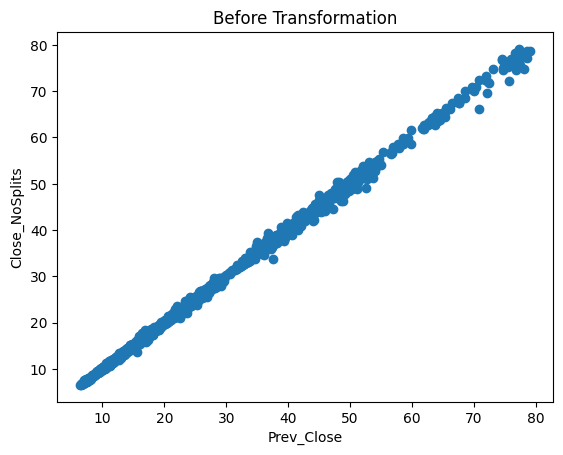

Correlation: 0.9994730675308261


In [3]:
plt.scatter(merged['Prev_Close'], merged['Close_NoSplits'])
plt.xlabel('Prev_Close')
plt.ylabel('Close_NoSplits')
plt.title('Before Transformation')
plt.show()
corr = merged['Prev_Close'].corr(merged['Close_NoSplits'])
print("Correlation:", corr)

Rarely does the closing price of AAPl change dramatically in a day and generally stays consistent.

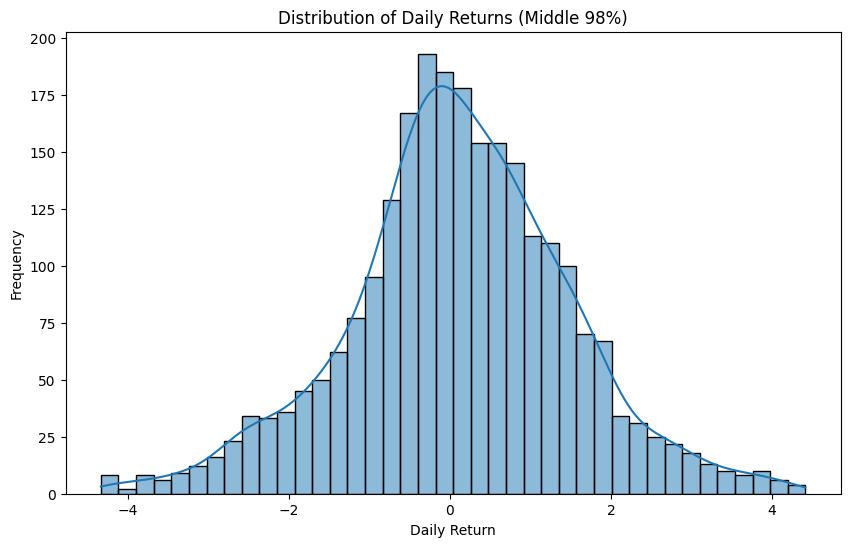

In [4]:
low = merged['Daily_Return'].quantile(0.01)
high = merged['Daily_Return'].quantile(0.99)

filtered = merged[(merged['Daily_Return'] >= low) & (merged['Daily_Return'] <= high)]

plt.figure(figsize=(10,6))
sb.histplot(filtered['Daily_Return'], bins=40, kde=True)

plt.title('Distribution of Daily Returns (Middle 98%)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.show()

There is a normal distribution of daily return for AAPl and shows that half of the time results in a loss and the other half results in a profit, and that majority of returns is nearly zero.

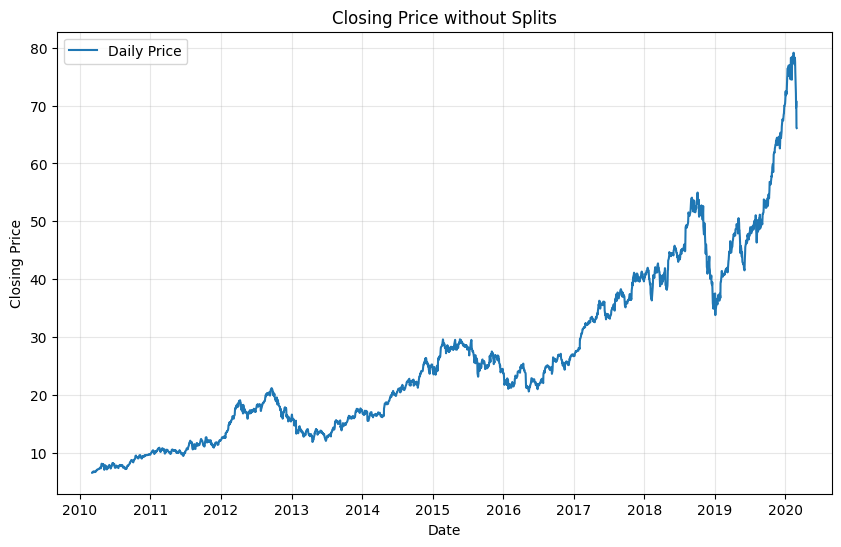

In [5]:
plt.figure(figsize=(10,6))

plt.plot(merged['Date'], merged['Close_NoSplits'], label='Daily Price')

plt.title("Closing Price without Splits")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

This line graph shows the change in closing price without splits of AAPL stocks over 10 years. The graph represents an upward trend with fluctuations going up and down and a sudden spike in prices in 2019.

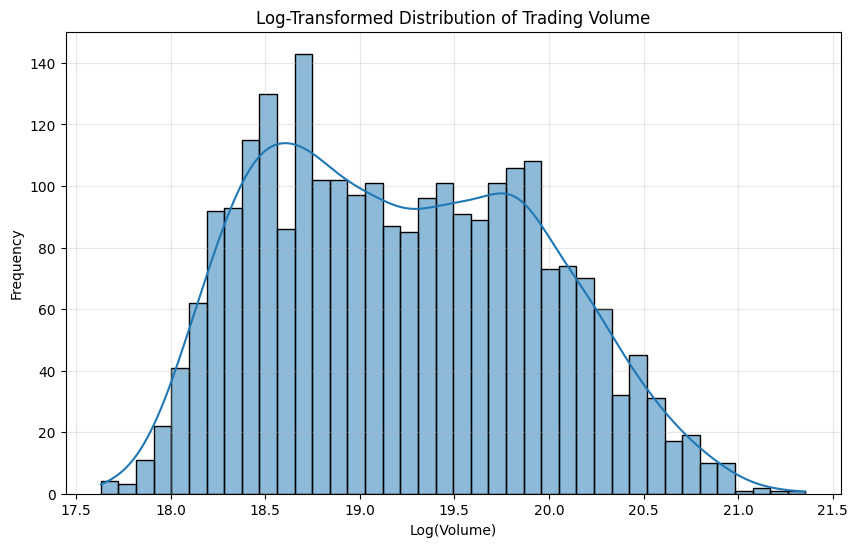

In [6]:
plt.figure(figsize=(10,6))

log_volume = np.log1p(merged['Volume_NoSplits'])

sb.histplot(log_volume, bins=40, kde=True)

plt.title('Log-Transformed Distribution of Trading Volume')
plt.xlabel('Log(Volume)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.show()

After applying a log transformation to the volume of AAPL stocks sold in a day we can see that the distribution between volume and frequency is more symmetric. Most values have a logarithmic volume between 18.5 and 20. There are also less outliers and both sides of the graph. With a reduced skewness

SECITON 3: Baseline Model

In [24]:
#part 3a

def mse(y, yhat):
    return np.mean((y-yhat) ** 2)

def rmse(y, yhat):
    return np.sqrt(mse(y, yhat))

x = merged['Prev_Close'].values
y = merged['Close_NoSplits'].values
constant = np.mean(y)
yhat_const = np.ones(len(y)) * constant

const_mse = mse(y, yhat_const)
const_rmse = rmse(y, yhat_const)

print("Constant Model MSE:", const_mse)
print("Constant Model RMSE:", const_rmse)


Constant Model MSE: 226.23479746031438
Constant Model RMSE: 15.041103598483536


The constant model predicts the average closing price for all days. The RMSE is approximately 15 dollars meaning the predictions are off by about 15 dollars compared to actual closing price on average. Since the closing price is measured in dollars, the error is also in dollars. This RMSE serves as a baseline, and any useful predictive model should have an RMSE below 15 dollars.

SECTION 4: Simple Linear Regression

Slope: 1.0005259926144712
Intercept: 0.010003502917378171


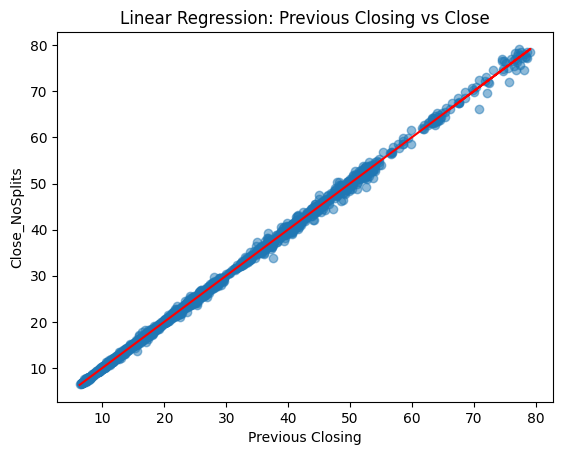

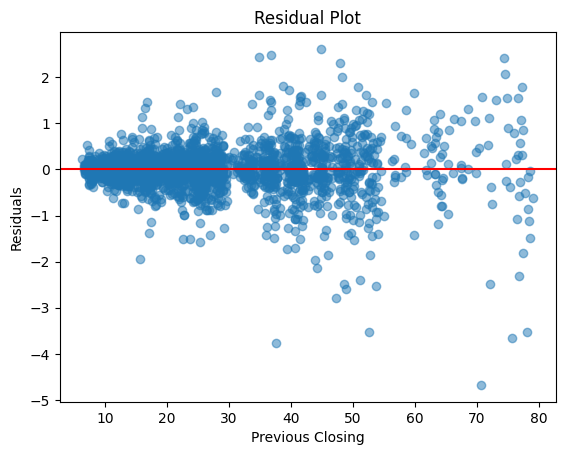

In [26]:
from sklearn.linear_model import LinearRegression
x = x.reshape(-1,1)

model = LinearRegression()
model.fit(x, y)

slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)
plt.scatter(x, y, alpha=0.5)

yhat = model.predict(x)

plt.plot(x, yhat, color='red')

plt.xlabel("Previous Closing")
plt.ylabel("Close_NoSplits")
plt.title("Linear Regression: Previous Closing vs Close")
plt.show()
residuals = y - yhat

plt.scatter(x, residuals, alpha=0.5)
plt.axhline(0, color='red')

plt.xlabel("Previous Closing")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The scatter plot shows a very strong correlation between closing price and the closing price of the day before. The slope of 1.00 shows that a 1 dollar increase from the previous day will result to about a 1 dollar increase in the current closing price. The residual plot shows that the errors are centered around 0 indicating that the model is neither over or underpredicting. However, has the previous closing price increases so does the variance in error and it becomes more likely that the model is less accurate. Overall, the model demonstrates that the previous day's closing price is a very strong predictor of current closing price.